# Дообучение RNN-эмбеддингов с разметкой

Этот ноутбук проверяет следующий исследовательский вопрос: ограничение текущих RNN-эмбеддингов связано с самой архитектурой `GRU` или с целевой функцией next-event prediction без разметки удержания.

В предыдущих экспериментах `GRU` хорошо решал задачу next-event prediction, но оценка удержания улучшалась умеренно. Поэтому здесь используется уже обученный `GRU`-энкодер и проводится supervised fine-tuning на пользовательские метки `retention_7d` и `retention_14d`.

## План

1. Зафиксировать `GRU + усреднение скрытых состояний` как базовый вариант с разметкой этого ноутбука.
2. Построить честные prefix-based метки при `PREFIX_LEN=150`.
3. Сравнить два режима с разметкой:
   - `frozen_head`: энкодер заморожен, обучается только linear classifier;
   - `finetuned`: энкодер и classifier дообучаются вместе.
4. Сравнить модели с разметкой с unsupervised `GRU mean` и табличными baseline-признаками из ablation способа pooling.
5. Сохранить дообученная checkpoints, эмбеддинги и таблицу метрик.

In [1]:
from pathlib import Path
import copy
import json
import os
import sys

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '8')

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = Path('/Users/fedornikonov/hse_recsys_rnn')
sys.path.append(str(PROJECT_ROOT))

from src.data import PreparedSequences, load_prepared_sequences
from src.downstream import build_base_meta, build_meta_for_prefix
from src.models import GRUEncoder
from src.supervised import (
    PrefixLabelDataset,
    SupervisedRNNClassifier,
    binary_pos_weight,
    build_supervised_embeddings,
    evaluate_supervised_classifier,
    train_supervised_classifier,
)
from src.train import choose_device, seed_everything

sns.set_theme(style='whitegrid', context='notebook')
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(20)

def to_pandas(df: pl.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(df.to_dicts())

DATA_DIR = PROJECT_ROOT / 'artifacts/data'
RNN_DIR = PROJECT_ROOT / 'artifacts/rnn'
POOLING_DIR = PROJECT_ROOT / 'artifacts/pooling_ablation'
OUT_DIR = PROJECT_ROOT / 'artifacts/supervised_finetuning'
CHECKPOINT_DIR = OUT_DIR / 'checkpoints'
EMBEDDINGS_DIR = OUT_DIR / 'embeddings'
FIGURES_DIR = OUT_DIR / 'figures'
for path in [OUT_DIR, CHECKPOINT_DIR, EMBEDDINGS_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
PREFIX_LEN = 150
HORIZONS = {'retention_7d': 7, 'retention_14d': 14}
POOLING = 'mean'
BATCH_SIZE = 256
FROZEN_EPOCHS = 6
FINETUNE_EPOCHS = 5
FROZEN_LR = 1e-3
FINETUNE_LR = 2e-4
DROPOUT = 0.15

seed_everything(SEED)
device = choose_device()
print(f'device={device}, prefix_len={PREFIX_LEN}, pooling={POOLING}')

device=mps, prefix_len=150, pooling=mean


## 1. Данные, метки и базовый GRU энкодер

Используется тот же `checkpoint `GRU`, который обучался на next-event prediction. Метки строятся по финальному prefix-based протоколу: пользователь попадает в downstream-выборку только если у него есть полный префикс из `150` событий и достаточный будущий горизонт для проверки удержания.

In [2]:
prepared = load_prepared_sequences(DATA_DIR)
split_users = pl.read_parquet(DATA_DIR / 'split_users.parquet')
sequence_df = pl.read_parquet(DATA_DIR / 'user_sequences.parquet')

base_meta, data_end_ts = build_base_meta(str(DATA_DIR / 'clean_events' / '*.parquet'), prepared.user_ids)
meta_df, label_summary_df = build_meta_for_prefix(
    base_meta,
    prefix_len=PREFIX_LEN,
    horizons=HORIZONS,
    data_end_ts=data_end_ts,
)
label_frame = (
    meta_df.select(['appmetrica_device_id', 'prefix_len_time', *HORIZONS.keys()])
    .join(split_users, on='appmetrica_device_id', how='inner')
    .join(sequence_df, on='appmetrica_device_id', how='inner')
)

config = json.loads((RNN_DIR / 'rnn_config.json').read_text(encoding='utf-8'))
checkpoint = torch.load(RNN_DIR / 'rnn_encoder.pt', map_location='cpu')
base_encoder = GRUEncoder(
    vocab_size=len(prepared.event2idx),
    event_dim=config['event_dim'],
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    dropout=config['dropout'],
)
base_encoder.load_state_dict(checkpoint['model_state_dict'])

label_summary_df

prefix_len,label,valid_users,positive_rate
i64,str,i64,f64
150,"""retention_7d""",18547,0.281124
150,"""retention_14d""",15207,0.181758


### Вывод по меткам для обучения с разметкой

Supervised fine-tuning использует тот же `prefix_len=150` и те же метки, что эксперименты последующей оценки и pooling. Поэтому сравнение с `GRU mean` из `05` остаётся честным: меняется только objective обучения, а не протокол данных. При этом важно помнить, что после пересчёта `05` лучшим unsupervised агрегация стал `GRU max`; здесь проверяется именно supervised-адаптация `усреднение скрытых состояний`, а не полный sweep supervised агрегация-стратегий.


In [3]:
setup_df = pl.DataFrame(
    {
        'parameter': ['users_total', 'vocab_size', 'prefix_len', 'pooling', 'hidden_dim', 'frozen_epochs', 'finetune_epochs'],
        'value': [str(len(prepared.user_ids)), str(len(prepared.event2idx)), str(PREFIX_LEN), POOLING, str(config['hidden_dim']), str(FROZEN_EPOCHS), str(FINETUNE_EPOCHS)],
    }
)
setup_df

parameter,value
str,str
"""users_total""","""52495"""
"""vocab_size""","""81"""
"""prefix_len""","""150"""
"""pooling""","""mean"""
"""hidden_dim""","""128"""
"""frozen_epochs""","""6"""
"""finetune_epochs""","""5"""


## 2. Dataset builders

Для каждого целевая метка собирается отдельная train/val/test выборка, потому что валидность `retention_7d` и `retention_14d` отличается из-за разного будущего горизонта. Все модели используют одинаковые первые `150` событий пользователя.

In [4]:
def subset_prepared(df: pl.DataFrame) -> PreparedSequences:
    return PreparedSequences(
        user_ids=df['appmetrica_device_id'].to_list(),
        user_sequences=df['sequence'].to_list(),
        event2idx=prepared.event2idx,
    )


def build_label_datasets(label_name: str):
    valid = label_frame.filter(pl.col(label_name).is_not_null()).sort('appmetrica_device_id')
    datasets = {}
    summaries = []
    for split_name in ['train', 'val', 'test']:
        split_df = valid.filter(pl.col('split') == split_name)
        dataset = PrefixLabelDataset(
            split_df['appmetrica_device_id'].to_list(),
            split_df['sequence'].to_list(),
            split_df[label_name].to_list(),
            prefix_len=PREFIX_LEN,
        )
        datasets[split_name] = dataset
        summaries.append(
            {
                'label': label_name,
                'split': split_name,
                'num_users': len(dataset),
                'positive_rate': float(split_df[label_name].mean()) if split_df.height else None,
            }
        )
    return datasets, pl.DataFrame(summaries)

summary_tables = []
datasets_by_label = {}
for label in HORIZONS:
    datasets, summary = build_label_datasets(label)
    datasets_by_label[label] = datasets
    summary_tables.append(summary)

dataset_summary_df = pl.concat(summary_tables).sort(['label', 'split'])
dataset_summary_df.write_csv(OUT_DIR / 'supervised_dataset_summary.csv')
dataset_summary_df

label,split,num_users,positive_rate
str,str,i64,f64
"""retention_14d""","""test""",2303,0.184542
"""retention_14d""","""train""",10586,0.180427
"""retention_14d""","""val""",2318,0.185073
"""retention_7d""","""test""",2805,0.281283
"""retention_7d""","""train""",12959,0.277336
"""retention_7d""","""val""",2783,0.298599


## 3. Обучение frozen head и дообученная GRU

`frozen_head` проверяет, насколько уже обученный энкодере, обученном на предсказании следующего события линейно пригоден для удержания. `finetuned` проверяет, можно ли улучшить пользовательские эмбеддинги, если дообучить сам энкодер под пользовательский objective.

In [5]:
def make_model(train_encoder: bool) -> SupervisedRNNClassifier:
    encoder = copy.deepcopy(base_encoder).to(device)
    model = SupervisedRNNClassifier(
        encoder,
        hidden_dim=config['hidden_dim'],
        pooling=POOLING,
        dropout=DROPOUT,
    ).to(device)
    if train_encoder:
        model.unfreeze_encoder()
    else:
        model.freeze_encoder()
    return model


def run_supervised_experiment(label_name: str, mode: str):
    train_encoder = mode == 'finetuned'
    datasets = datasets_by_label[label_name]
    train_loader = DataLoader(datasets['train'], batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(datasets['val'], batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(datasets['test'], batch_size=BATCH_SIZE, shuffle=False)

    model = make_model(train_encoder=train_encoder)
    train_labels = [item[2].item() for item in datasets['train']]
    pos_weight = binary_pos_weight(train_labels)
    epochs = FINETUNE_EPOCHS if train_encoder else FROZEN_EPOCHS
    lr = FINETUNE_LR if train_encoder else FROZEN_LR

    history = train_supervised_classifier(
        model,
        train_loader,
        device=device,
        epochs=epochs,
        lr=lr,
        pos_weight=pos_weight,
    )

    rows = []
    for split_name, loader in [('val', val_loader), ('test', test_loader)]:
        metrics = evaluate_supervised_classifier(model, loader, device=device)
        rows.append(
            {
                'label': label_name,
                'mode': mode,
                'split': split_name,
                'loss': metrics['loss'],
                'roc_auc': metrics['roc_auc'],
                'pr_auc': metrics['pr_auc'],
                'num_users': metrics['num_users'],
                'pos_weight': pos_weight,
            }
        )

    checkpoint_path = CHECKPOINT_DIR / f'gru_mean_{mode}_{label_name}.pt'
    torch.save(
        {
            'model_state_dict': model.state_dict(),
            'label': label_name,
            'mode': mode,
            'prefix_len': PREFIX_LEN,
            'pooling': POOLING,
            'config': config,
            'history': history,
            'pos_weight': pos_weight,
        },
        checkpoint_path,
    )

    embeddings_df = build_supervised_embeddings(
        model,
        datasets['test'],
        batch_size=BATCH_SIZE,
        device=device,
    )
    embeddings_path = EMBEDDINGS_DIR / f'test_embeddings_gru_mean_{mode}_{label_name}.parquet'
    embeddings_df.write_parquet(embeddings_path)

    history_rows = [
        {'label': label_name, 'mode': mode, 'epoch': epoch, 'train_loss': value}
        for epoch, value in enumerate(history, start=1)
    ]
    return pl.DataFrame(rows), pl.DataFrame(history_rows), checkpoint_path, embeddings_path

metric_frames = []
history_frames = []
artifact_rows = []
for label in HORIZONS:
    for mode in ['frozen_head', 'finetuned']:
        metrics, history, checkpoint_path, embeddings_path = run_supervised_experiment(label, mode)
        metric_frames.append(metrics)
        history_frames.append(history)
        artifact_rows.append(
            {
                'label': label,
                'mode': mode,
                'checkpoint': str(checkpoint_path.relative_to(PROJECT_ROOT)),
                'test_embeddings': str(embeddings_path.relative_to(PROJECT_ROOT)),
            }
        )

supervised_metrics_df = pl.concat(metric_frames).sort(['label', 'split', 'mode'])
supervised_history_df = pl.concat(history_frames).sort(['label', 'mode', 'epoch'])
supervised_artifacts_df = pl.DataFrame(artifact_rows).sort(['label', 'mode'])

supervised_metrics_df.write_csv(OUT_DIR / 'supervised_metrics.csv')
supervised_history_df.write_csv(OUT_DIR / 'supervised_training_history.csv')
supervised_artifacts_df.write_csv(OUT_DIR / 'supervised_artifacts.csv')
supervised_metrics_df

label,mode,split,loss,roc_auc,pr_auc,num_users,pos_weight
str,str,str,f64,f64,f64,i64,f64
"""retention_14d""","""finetuned""","""test""",0.635695,0.697533,0.361869,2303,4.542408
"""retention_14d""","""frozen_head""","""test""",0.666088,0.692937,0.344994,2303,4.542408
"""retention_14d""","""finetuned""","""val""",0.631086,0.717553,0.382261,2318,4.542408
"""retention_14d""","""frozen_head""","""val""",0.656355,0.712796,0.369297,2318,4.542408
"""retention_7d""","""finetuned""","""test""",0.619777,0.68824,0.486068,2805,2.605732
"""retention_7d""","""frozen_head""","""test""",0.651222,0.686875,0.486162,2805,2.605732
"""retention_7d""","""finetuned""","""val""",0.624784,0.67444,0.480223,2783,2.605732
"""retention_7d""","""frozen_head""","""val""",0.653484,0.663238,0.4805,2783,2.605732


In [6]:
supervised_history_df

label,mode,epoch,train_loss
str,str,i64,f64
"""retention_14d""","""finetuned""",1,1.118558
"""retention_14d""","""finetuned""",2,1.044705
"""retention_14d""","""finetuned""",3,1.030104
"""retention_14d""","""finetuned""",4,1.023319
"""retention_14d""","""finetuned""",5,1.018461
"""retention_14d""","""frozen_head""",1,1.144908
"""retention_14d""","""frozen_head""",2,1.062501
"""retention_14d""","""frozen_head""",3,1.036564
"""retention_14d""","""frozen_head""",4,1.03213


### Вывод по обучению с разметкой

`frozen_head` проверяет, насколько сигнал удержания уже линейно доступен в энкодере, обученном на предсказании следующего события. Дообучение разрешает менять сам энкодер под удержание. Разница между ними показывает, сколько качества можно получить именно за счёт адаптации с разметкой, а не только за счёт нового классификатора поверх фиксированных эмбеддингов.


## 4. Сравнение с эмбеддингами без разметки удержания и baseline

Здесь модели с разметкой сравниваются с результатами ablation способа pooling. Это позволяет понять, даёт ли пользовательский дообучение преимущество над `GRU mean`, обученным только на next-event prediction.

In [7]:
pooling_metrics = pl.read_csv(POOLING_DIR / 'pooling_downstream_metrics.csv')
reference_rows = []
for label_name in HORIZONS:
    for feature_set, mode_name in [
        ('Baseline', 'baseline_xgb'),
        ('GRU mean', 'next_event_gru_mean_xgb'),
        ('Baseline + GRU mean', 'baseline_plus_next_event_gru_mean_xgb'),
    ]:
        subset = pooling_metrics.filter(
            (pl.col('split') == 'test')
            & (pl.col('label') == label_name)
            & (pl.col('feature_set') == feature_set)
        )
        if subset.height:
            reference_rows.append(
                {
                    'label': label_name,
                    'mode': mode_name,
                    'split': 'test',
                    'roc_auc': float(subset['roc_auc'][0]),
                    'pr_auc': float(subset['pr_auc'][0]),
                    'num_users': int(subset['num_users'][0]),
                }
            )

reference_df = pl.DataFrame(reference_rows)
supervised_test_df = supervised_metrics_df.filter(pl.col('split') == 'test').select(
    ['label', 'mode', 'split', 'roc_auc', 'pr_auc', 'num_users']
)
comparison_df = pl.concat([reference_df, supervised_test_df], how='diagonal').sort(['label', 'mode'])
comparison_df.write_csv(OUT_DIR / 'supervised_vs_reference_test_metrics.csv')
comparison_df

label,mode,split,roc_auc,pr_auc,num_users
str,str,str,f64,f64,i64
"""retention_14d""","""baseline_plus_next_event_gru_m…","""test""",0.697874,0.366251,2303
"""retention_14d""","""baseline_xgb""","""test""",0.683047,0.343962,2303
"""retention_14d""","""finetuned""","""test""",0.697533,0.361869,2303
"""retention_14d""","""frozen_head""","""test""",0.692937,0.344994,2303
"""retention_14d""","""next_event_gru_mean_xgb""","""test""",0.693713,0.360352,2303
"""retention_7d""","""baseline_plus_next_event_gru_m…","""test""",0.675091,0.475728,2805
"""retention_7d""","""baseline_xgb""","""test""",0.663872,0.46206,2805
"""retention_7d""","""finetuned""","""test""",0.68824,0.486068,2805
"""retention_7d""","""frozen_head""","""test""",0.686875,0.486162,2805


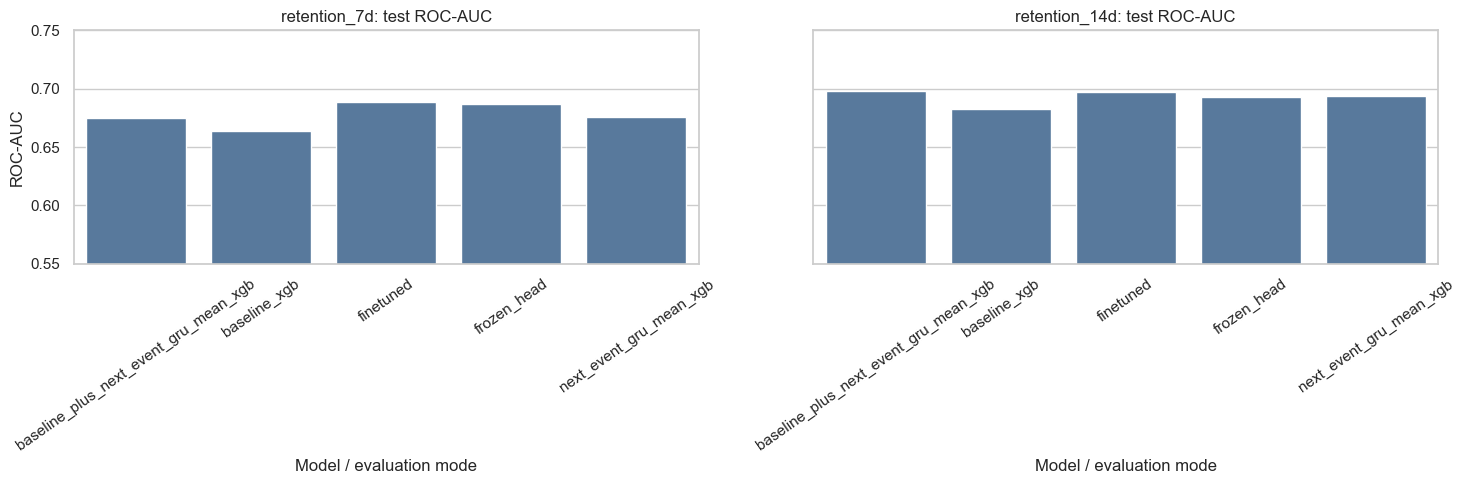

In [8]:
plot_df = to_pandas(comparison_df)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, label_name in zip(axes, ['retention_7d', 'retention_14d']):
    subset = plot_df[plot_df['label'] == label_name]
    sns.barplot(data=subset, x='mode', y='roc_auc', ax=ax, color='#4C78A8')
    ax.set_title(f'{label_name}: test ROC-AUC')
    ax.set_xlabel('Model / evaluation mode')
    ax.set_ylabel('ROC-AUC')
    ax.set_ylim(0.55, 0.75)
    ax.tick_params(axis='x', rotation=35)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'supervised_roc_auc_comparison.png', dpi=180)
plt.show()

### Вывод по сравнению с референсными моделями

Дообучение даёт умеренный прирост над `frozen_head` по ROC-AUC, но не меняет общую картину радикально. Для `retention_7d` дообученная `GRU mean` даёт лучший ROC-AUC в этой таблице (`0.6882`), а по PR-AUC почти равен `frozen_head` (`0.4861` против `0.4862`). Для `retention_14d` дообученная модель (`0.6975 / 0.3619`) почти совпадает с `Baseline + next-event GRU mean` (`0.6979 / 0.3663`). С учётом результатов `05` это не превосходит лучший unsupervised `GRU max` на `retention_14d` (`0.7025 / 0.3663`).


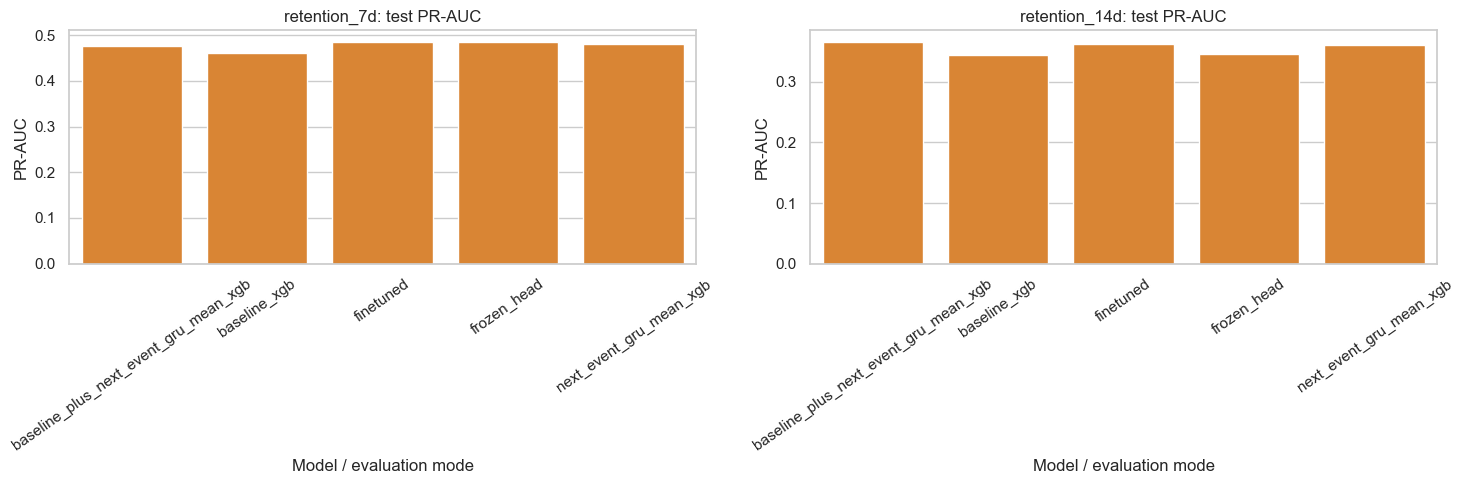

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
for ax, label_name in zip(axes, ['retention_7d', 'retention_14d']):
    subset = plot_df[plot_df['label'] == label_name]
    sns.barplot(data=subset, x='mode', y='pr_auc', ax=ax, color='#F58518')
    ax.set_title(f'{label_name}: test PR-AUC')
    ax.set_xlabel('Model / evaluation mode')
    ax.set_ylabel('PR-AUC')
    ax.tick_params(axis='x', rotation=35)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'supervised_pr_auc_comparison.png', dpi=180)
plt.show()

## Итог

Supervised fine-tuning проверило, можно ли улучшить пользовательские RNN-эмбеддинги, если оптимизировать энкодер не только под next-event prediction, но и напрямую под пользовательскую целевую функцию удержания.

Основные экспериментальные выводы:

- `frozen_head` уже даёт качество выше табличных baseline-признаков по ROC-AUC: для `retention_7d` `0.6869` против `0.6639`, для `retention_14d` `0.6929` против `0.6830`. Это означает, что `GRU + усреднение скрытых состояний` эмбеддинг линейно содержит часть сигнала удержания.
- Дообучение энкодера даёт небольшой дополнительный прирост над `frozen_head` по ROC-AUC: на `retention_7d` ROC-AUC растёт с `0.6869` до `0.6882`, а на `retention_14d` — с `0.6929` до `0.6975`. По PR-AUC картина смешанная: `retention_14d` улучшается с `0.3450` до `0.3619`, а на `retention_7d` `frozen_head` и `finetuned` практически равны (`0.4862` и `0.4861`).
- По сравнению с XGBoost на `GRU mean` эмбеддинг результат дообучения с разметкой лучше на `retention_7d`: дообученная GRU даёт ROC-AUC `0.6882` против `0.6756` и PR-AUC `0.4861` против `0.4812`. На `retention_14d` дообученная GRU почти равна `Baseline + GRU mean` по ROC-AUC (`0.6975` против `0.6979`) и немного уступает по PR-AUC (`0.3619` против `0.3663`).
- Если учитывать ablation способа pooling из `05`, самый сильный unsupervised вариант на этом этапе — `GRU h128 max`: `0.6827 / 0.4800` на `retention_7d` и `0.7025 / 0.3663` на `retention_14d`. Поэтому supervised fine-tuning `усреднение скрытых состояний` полезен как отдельная проверка objective, но не заменяет ablation способа pooling.

Следовательно, проблема не только в objective: энкодере, обученном на предсказании следующего события уже даёт достаточно сильные эмбеддинги, а supervised дообучение улучшает `усреднение скрытых состояний` умеренно, но не радикально. Это важный сдержанный результат, потому что он показывает границу пользы прямого дообучения на текущей постановке retention.

Практический вывод для финального пайплайна: supervised `GRU mean` не становится основным универсальным эмбеддинг, а остаётся дополнительной проверкой пользовательский objective. Финальный без разметки удержания RNN-кандидат после capacity/stability этапов (`10` и `11`) — `GRU h256 l1 max`; этот ноутбук показывает, что прямое дообучение под retention даёт полезный, но не решающий прирост.

С точки зрения интерпретации это не провал supervised-подхода, а ограничение текущей постановки: сигнал удержания уже хорошо извлекается из next-event эмбеддинги, поэтому прямое дообучение даёт умеренный, а не радикальный прирост. Утечки здесь не видно: train/val/test остаются user-disjoint, энкодер дообучается только на train метки, validation используется для выбора чекпойнта, а test открывается только для финальной оценки.

In [10]:
config_out = {
    'seed': SEED,
    'prefix_len': PREFIX_LEN,
    'pooling': POOLING,
    'batch_size': BATCH_SIZE,
    'frozen_epochs': FROZEN_EPOCHS,
    'finetune_epochs': FINETUNE_EPOCHS,
    'frozen_lr': FROZEN_LR,
    'finetune_lr': FINETUNE_LR,
    'dropout': DROPOUT,
    'horizons': HORIZONS,
    'base_checkpoint': str((RNN_DIR / 'rnn_encoder.pt').relative_to(PROJECT_ROOT)),
    'main_embedding_artifact': 'artifacts/rnn/main/gru_mean_prefix150_embeddings.parquet',
}
(OUT_DIR / 'supervised_finetuning_config.json').write_text(json.dumps(config_out, ensure_ascii=False, indent=2), encoding='utf-8')

saved_paths = {
    'metrics': OUT_DIR / 'supervised_metrics.csv',
    'comparison': OUT_DIR / 'supervised_vs_reference_test_metrics.csv',
    'history': OUT_DIR / 'supervised_training_history.csv',
    'artifacts': OUT_DIR / 'supervised_artifacts.csv',
    'figures': FIGURES_DIR,
    'config': OUT_DIR / 'supervised_finetuning_config.json',
}
saved_paths

{'metrics': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/supervised_finetuning/supervised_metrics.csv'),
 'comparison': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/supervised_finetuning/supervised_vs_reference_test_metrics.csv'),
 'history': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/supervised_finetuning/supervised_training_history.csv'),
 'artifacts': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/supervised_finetuning/supervised_artifacts.csv'),
 'figures': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/supervised_finetuning/figures'),
 'config': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/supervised_finetuning/supervised_finetuning_config.json')}